In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [30]:
# 1. define the state.
class BMIClass(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float 
    category: str

In [26]:

def calculate_bmi(state: BMIClass) -> BMIClass:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)
    state['bmi'] = bmi

    return state

In [ ]:
def label_bmi(state: BMIClass) -> BMIClass:

    bmi = state['bmi']
    

In [27]:
# Define graph:
graph = StateGraph(BMIClass)

# add nodes to the graph
graph.add_node('calculate_bmi', calculate_bmi)

# add edges to the graph
graph.add_edge(START, 'calculate_bmi')
graph.add_node('label_bmi', label_bmi)
graph.add_edge('calculate_bmi', END)
# compile the graph
workflow= graph.compile()


In [28]:
# execute the graph:

input_state = {'weight_kg': 20,'height_m': 1.72}

final_state = workflow.invoke(input_state)
print(final_state)

{'weight_kg': 20, 'height_m': 1.72, 'bmi': 6.760411032990807}


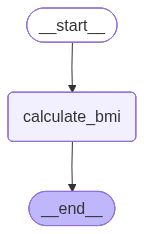

In [29]:
## visualization of graph:

from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)